In [84]:
%load_ext watermark


The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark


In [85]:
import os

from IPython.display import display
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp

import pylib  # noqa: F401


In [86]:
%watermark -diwmuv -iv


Last updated: 2026-04-01T00:39:28.434055-04:00

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.31.1

Compiler    : GCC 15.2.1 20260123 (Red Hat 15.2.1-7)
OS          : Linux
Release     : 6.19.6-200.fc43.x86_64
Machine     : x86_64
Processor   : 
CPU cores   : 14
Architecture: 64bit

seaborn   : 0.13.2
matplotlib: 3.9.2
pandas    : 2.2.3
teeplot   : 1.4.2
pylib     : 0.0.0

Watermark: 2.4.3



In [87]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2026-03-31-benchmark")
teeplot_subdir


'2026-03-31-benchmark'

## Prep Data


In [88]:
df = pd.read_csv("https://osf.io/utv5w/download")
display(df.describe()), display(df.head()), display(df.tail());


,n_leaves,seconds
count,2.910000e+03,1.356000e+03
mean,3.380676e+06,5.240682e+07
std,8.060839e+06,3.538082e+08
min,1.000000e+02,6.562000e-06
25%,1.000000e+03,4.628112e-03
50%,3.000000e+04,1.824170e-01
75%,1.000000e+06,6.095955e+01
max,3.000000e+07,4.804567e+09


,library,n_leaves,operation,seconds,status
0,phyloframe,100,load_newick,0.000611,NaN
1,phyloframe,100,save_newick,0.009734,NaN
2,phyloframe,100,preorder,NaN,NaN
3,phyloframe,100,postorder,0.000048,NaN
4,phyloframe,100,inorder,0.008569,NaN


,library,n_leaves,operation,seconds,status
2905,ete,3000000,newick_gzip_bytes,NaN,UNAVAILABLE
2906,ete,3000000,csv_bytes,NaN,UNAVAILABLE
2907,ete,3000000,csv_gzip_bytes,NaN,UNAVAILABLE
2908,ete,3000000,parquet_bytes,NaN,UNAVAILABLE
2909,ete,3000000,feather_bytes,NaN,UNAVAILABLE


## Example Plot


In [89]:
df["throughput"] = df["n_leaves"] / df["seconds"]


teeplots/2026-03-31-benchmark/col=operation+hue=library+kind=line+viz=relplot+x=tips+y=tips-per-sec+ext=.pdf
teeplots/2026-03-31-benchmark/col=operation+hue=library+kind=line+viz=relplot+x=tips+y=tips-per-sec+ext=.png


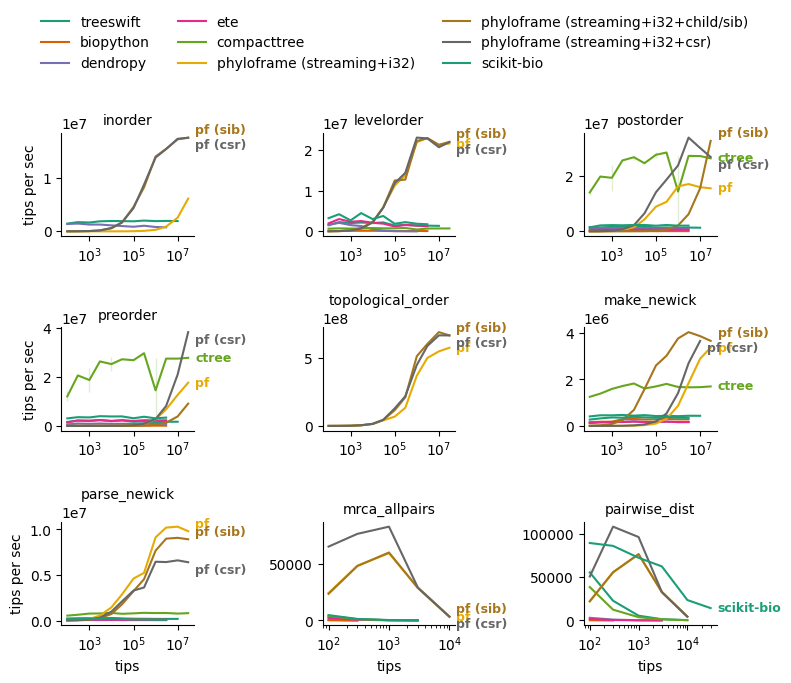

In [91]:
# 1. Extract the filtered data so we can easily reference it for labeling
plot_df = df[
    ~df["operation"].str.contains("bytes")
    & ~df["operation"].str.contains("save")
    & ~df["operation"].str.contains("load")
    & (df["library"] != "phyloframe")
    & (df["library"] != "phyloframe (in-memory)")
].copy()
plot_df["tips"] = plot_df["n_leaves"]
plot_df["tips per sec"] = plot_df["throughput"]

palette = sns.color_palette("Dark2", n_colors=len(unique_libs))
unique_libs = plot_df["library"].unique()
with tp.teed(
    sns.relplot,
    data=plot_df,
    x="tips",
    y="tips per sec",
    hue="library",
    col="operation",
    col_order=[
        "inorder",
        "levelorder",
        "postorder",
        "preorder",
        "topological_order",
        "make_newick",
        "parse_newick",
        "mrca_allpairs",
        "pairwise_dist",
    ],
    col_wrap=3,
    facet_kws={
        "sharex": False,
        "sharey": False,
    },
    kind="line",
    legend=True,
    palette=palette,
    teeplot_subdir=teeplot_subdir,
) as teed:

    # 2. Map colors to libraries so the text labels match the line colors
    color_dict = dict(zip(unique_libs, palette))

    # 3. Define a labeling function to map over each facet
    def label_line_ends(data, **kwargs):
        ax = plt.gca()
        maxmax = 0
        for library, group_df in (
            data.dropna(subset="tips per sec").groupby("library")
        ):
            if group_df.empty:
                continue

            # Find the coordinates for the largest x value (n_leaves)
            max_x_idx = group_df["tips"].idxmax()
            max_x = group_df.loc[max_x_idx, "tips"]
            max_y = group_df.loc[max_x_idx, "tips per sec"]
            maxmax = max(maxmax, max_y)

        for library, group_df in (
            data.dropna(subset="tips per sec").groupby("library")
        ):
            if group_df.empty:
                continue

            # Find the coordinates for the largest x value (n_leaves)
            max_x_idx = group_df["tips"].idxmax()
            max_x = group_df.loc[max_x_idx, "tips"]
            max_y = group_df.loc[max_x_idx, "tips per sec"]
            if max_y < maxmax / 2.5:
                continue

            if library == "phyloframe (streaming+i32)" and max_y == maxmax:
                suffix = "\n"
            else:
                suffix = ""
            # Place the text at the end of the line
            ax.annotate(
                (
                    library
                    .replace("streaming+i32+", "")
                    .replace("streaming+i32", "")
                    .replace("()", "")
                    .replace(
                        "phyloframe (csr)", "\nphyloframe (csr)"
                    )
                    .replace(
                        "phyloframe (child/sib)", "phyloframe (sib)\n"
                    )
                    .replace("phyloframe", "pf")
                    .replace("compacttree", "ctree")
                    + suffix
                ),
                xy=(max_x, max_y),
                xytext=(5, 0), # Offset 5 points to the right
                textcoords="offset points",
                ha="left",
                va="center",
                color=color_dict.get(library, "black"),
                fontweight="bold",
                fontsize=9,
                clip_on=False,
            )

    # 4. Apply the function to the underlying FacetGrid
    teed.map_dataframe(label_line_ends)

    teed.fig.set_size_inches(8, 6)
    teed.fig.tight_layout()
    teed.set_titles(col_template="{col_name}")
    teed.set(xscale="log")

    sns.move_legend(
        teed, "lower center",
        bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
    )
